Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB
Loading Yelp dataset...
Original shapes:
train.csv: (560000, 2)
test.csv : (38000, 2)

After cleaning:
Train shape: (560000, 2)
Test shape : (38000, 2)

Full split sizes:
Train: 504,000
Val  : 56,000
Test : 38,000

Train split distribution:
  Label 0: 252000 samples (50.00%)
  Label 1: 252000 samples (50.00%)

Validation split distribution:
  Label 0: 28000 samples (50.00%)
  Label 1: 28000 samples (50.00%)

Test split distribution:
  Label 0: 19000 samples (50.00%)
  Label 1: 19000 samples (50.00%)

Final working split sizes:
Train: 504,000
Val  : 56,000
Test : 38,000

Working Train split distribution:
  Label 0: 252000 samples (50.00%)
  Label 1: 252000 samples (50.00%)

Working Validation split distribution:
  Label 0: 28000 samples (50.00%)
  Label 1: 28000 samples (50.00%)

Working Test split distribution:
  

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/798k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]


Computing token statistics on a sample...
        split  avg_tokens_before  median_tokens_before  max_tokens_before  \
0       train           186.6533                 134.0               1397   
1  validation           185.9650                 134.0               1522   
2        test           188.4978                 136.0               1804   

   min_tokens_before  pct_over_max_length  truncation_count  truncation_rate  \
0                  4                22.81              2281           0.2281   
1                  4                22.64              1132           0.2264   
2                  4                23.32              1166           0.2332   

   avg_tokens_after  median_tokens_after  max_tokens_after  min_tokens_after  
0          144.8429                134.0               256                 4  
1          144.9840                134.0               256                 4  
2          146.3276                136.0               256                 4  
Saved: /con

...

Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Roc Auc
1,0.130416,0.113416,0.970750,0.972099,0.969321,0.970708,0.995742
2,0.087262,0.115614,0.973107,0.971055,0.975286,0.973166,0.996399


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training completed in 173 min 32.27 sec
Peak GPU memory during training: 3170.36 MB


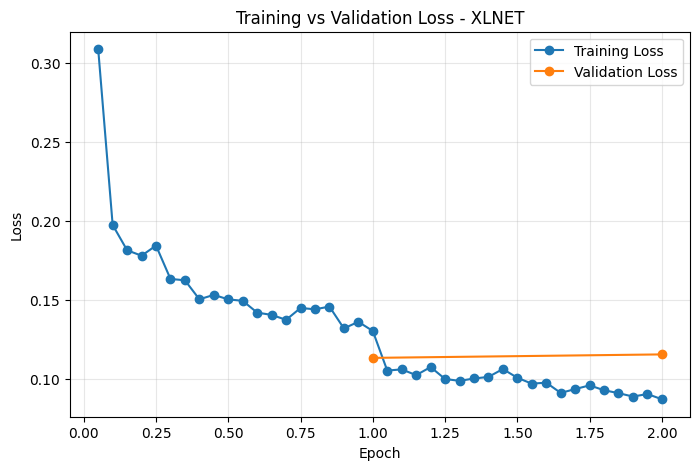

Saved: /content/drive/MyDrive/yelp_results_full_xlnet/xlnet_training_curves.png

Running test inference...



Test metrics:
accuracy: 0.9741
precision: 0.9725
recall: 0.9757
f1: 0.9741
roc_auc: 0.9965

Classification report:
              precision    recall  f1-score   support

    Negative       0.98      0.97      0.97     19000
    Positive       0.97      0.98      0.97     19000

    accuracy                           0.97     38000
   macro avg       0.97      0.97      0.97     38000
weighted avg       0.97      0.97      0.97     38000


Efficiency metrics:
Training time: 173 min 32.27 sec
Inference time: 2 min 17.34 sec
Inference latency/sample: 3.6143 ms
Inference throughput: 276.68 samples/sec
Training throughput: 96.81 samples/sec
Peak GPU memory (train): 3170.36 MB
Peak GPU memory (inference): 1755.56 MB


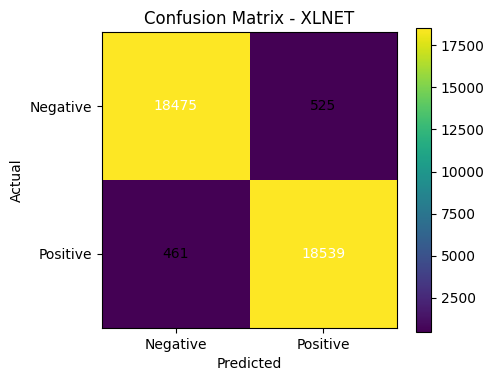

Saved: /content/drive/MyDrive/yelp_results_full_xlnet/xlnet_confusion_matrix.png


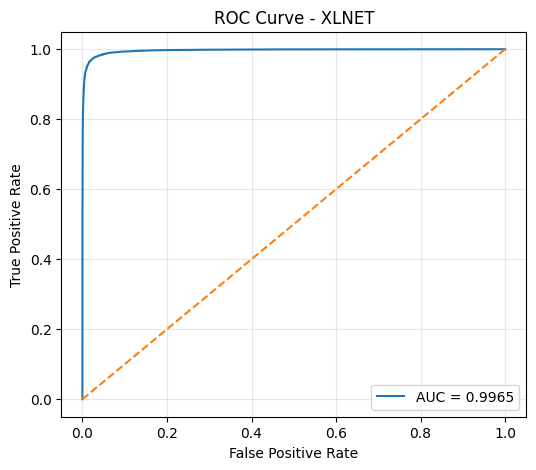

Saved: /content/drive/MyDrive/yelp_results_full_xlnet/xlnet_roc_curve.png
Saved: /content/drive/MyDrive/yelp_results_full_xlnet/xlnet_metrics.csv
Saved: /content/drive/MyDrive/yelp_results_full_xlnet/xlnet_test_predictions.csv
Saved: /content/drive/MyDrive/yelp_results_full_xlnet/xlnet_confusion_matrix_values.csv
Saved: /content/drive/MyDrive/yelp_results_full_xlnet/xlnet_classification_report.csv
Saved: /content/drive/MyDrive/yelp_results_full_xlnet/xlnet_training_log_history.csv

FINAL XLNET RESULTS
   model        checkpoint optimizer  max_length  batch_size  epochs  \
0  xlnet  xlnet-base-cased     AdamW         256           8       2   

   learning_rate  weight_decay  train_samples  val_samples  ...  \
0            0.0          0.01         504000        56000  ...   

   inference_throughput_samples_per_sec  training_throughput_samples_per_sec  \
0                              276.6795                              96.8089   

   peak_gpu_mem_train_mb  peak_gpu_mem_infer_mb  tra

In [ ]:
# Yelp Review Polarity - XLNet Full Dataset Baseline
# Google Colab A100-ready
# Full standalone XLNet run

# =========================
# 1. INSTALL DEPENDENCIES
# =========================
!pip install -q transformers datasets accelerate evaluate scikit-learn

# =========================
# 2. IMPORTS
# =========================
import os
import re
import time
import math
import random
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

warnings.filterwarnings("ignore")

# =========================
# 3. CONFIGURATION
# =========================
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

from google.colab import drive
drive.mount('/content/drive')

TRAIN_PATH = "/content/drive/MyDrive/yelp_review_polarity_csv/train.csv"
TEST_PATH = "/content/drive/MyDrive/yelp_review_polarity_csv/test.csv"
OUTPUT_DIR = "/content/drive/MyDrive/yelp_results_full_xlnet"
os.makedirs(OUTPUT_DIR, exist_ok=True)

PILOT_MODE = False
PILOT_TRAIN_SIZE = 5000
PILOT_VAL_SIZE = 1000
PILOT_TEST_SIZE = 1000

VAL_SIZE = 0.1
MAX_LENGTH = 256
NUM_LABELS = 2
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
EARLY_STOPPING_PATIENCE = 1

MODEL_NAME = "xlnet"
CHECKPOINT = "xlnet-base-cased"
BATCH_SIZE = 8
OPTIMIZER_NAME = "AdamW"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# =========================
# 4. HELPERS
# =========================
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text)
    text = text.replace("<br />", " ")
    text = text.replace("\n", " ")
    text = text.replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def print_split_distribution(name: str, labels: pd.Series):
    counts = labels.value_counts().sort_index()
    proportions = labels.value_counts(normalize=True).sort_index() * 100
    print(f"\n{name} split distribution:")
    for label in counts.index:
        print(f"  Label {label}: {counts[label]} samples ({proportions[label]:.2f}%)")


def stratified_subsample(df: pd.DataFrame, n_samples: int, label_col: str = "label", seed: int = 42) -> pd.DataFrame:
    if n_samples >= len(df):
        return df.sample(frac=1, random_state=seed).reset_index(drop=True)

    sampled_parts = []
    label_counts = df[label_col].value_counts(normalize=True)

    allocated = {}
    total_allocated = 0
    labels_sorted = sorted(label_counts.index)

    for i, label in enumerate(labels_sorted):
        if i < len(labels_sorted) - 1:
            count = int(round(label_counts[label] * n_samples))
            allocated[label] = count
            total_allocated += count
        else:
            allocated[label] = n_samples - total_allocated

    for label, count in allocated.items():
        label_df = df[df[label_col] == label]
        sampled_parts.append(label_df.sample(n=count, random_state=seed))

    sampled_df = pd.concat(sampled_parts).sample(frac=1, random_state=seed).reset_index(drop=True)
    return sampled_df


def save_dataframe(df: pd.DataFrame, filename: str):
    path = os.path.join(OUTPUT_DIR, filename)
    df.to_csv(path, index=False)
    print(f"Saved: {path}")


def compute_basic_metrics(labels, preds, probs):
    accuracy = accuracy_score(labels, preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    roc_auc = roc_auc_score(labels, probs)
    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "roc_auc": roc_auc,
    }


def format_seconds(seconds: float) -> str:
    if seconds < 60:
        return f"{seconds:.2f} sec"
    minutes = int(seconds // 60)
    rem = seconds % 60
    return f"{minutes} min {rem:.2f} sec"


class TextClassificationDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


@dataclass
class TokenStats:
    avg_tokens_before: float
    median_tokens_before: float
    max_tokens_before: int
    min_tokens_before: int
    pct_over_max_length: float
    truncation_count: int
    truncation_rate: float
    avg_tokens_after: float
    median_tokens_after: float
    max_tokens_after: int
    min_tokens_after: int


def compute_token_stats_sampled(texts, tokenizer, max_length=256, sample_size=10000, seed=42):
    if len(texts) > sample_size:
        rng = np.random.default_rng(seed)
        idx = rng.choice(len(texts), size=sample_size, replace=False)
        texts = [texts[i] for i in idx]

    lengths_before = []
    lengths_after = []
    truncation_count = 0

    for text in texts:
        ids_before = tokenizer.encode(text, add_special_tokens=True, truncation=False)
        len_before = len(ids_before)
        lengths_before.append(len_before)

        enc_after = tokenizer(
            text,
            truncation=True,
            max_length=max_length,
            add_special_tokens=True,
        )
        len_after = len(enc_after["input_ids"])
        lengths_after.append(len_after)

        if len_before > max_length:
            truncation_count += 1

    n = len(texts)
    return TokenStats(
        avg_tokens_before=float(np.mean(lengths_before)),
        median_tokens_before=float(np.median(lengths_before)),
        max_tokens_before=int(np.max(lengths_before)),
        min_tokens_before=int(np.min(lengths_before)),
        pct_over_max_length=(truncation_count / n) * 100,
        truncation_count=int(truncation_count),
        truncation_rate=truncation_count / n,
        avg_tokens_after=float(np.mean(lengths_after)),
        median_tokens_after=float(np.median(lengths_after)),
        max_tokens_after=int(np.max(lengths_after)),
        min_tokens_after=int(np.min(lengths_after)),
    )


def plot_training_curves(log_history, model_name):
    train_logs = [x for x in log_history if "loss" in x and "epoch" in x and "eval_loss" not in x]
    eval_logs = [x for x in log_history if "eval_loss" in x and "epoch" in x]

    train_df_hist = pd.DataFrame(train_logs)
    eval_df_hist = pd.DataFrame(eval_logs)

    if train_df_hist.empty or eval_df_hist.empty:
        print(f"Skipping training curve plot for {model_name}: insufficient logs.")
        return None

    train_epoch_loss = train_df_hist.groupby("epoch", as_index=False)["loss"].mean()
    eval_epoch_loss = eval_df_hist.groupby("epoch", as_index=False)["eval_loss"].mean()

    plt.figure(figsize=(8, 5))
    plt.plot(train_epoch_loss["epoch"], train_epoch_loss["loss"], marker="o", label="Training Loss")
    plt.plot(eval_epoch_loss["epoch"], eval_epoch_loss["eval_loss"], marker="o", label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training vs Validation Loss - {model_name.upper()}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    save_path = os.path.join(OUTPUT_DIR, f"{model_name}_training_curves.png")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
    return save_path


def plot_confusion_matrix(cm, model_name):
    plt.figure(figsize=(5, 4))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix - {model_name.upper()}")
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["Negative", "Positive"])
    plt.yticks(tick_marks, ["Negative", "Positive"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    thresh = cm.max() / 2
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i, format(cm[i, j], "d"),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black"
            )

    save_path = os.path.join(OUTPUT_DIR, f"{model_name}_confusion_matrix.png")
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
    return save_path


def plot_roc(labels, probs, model_name):
    fpr, tpr, _ = roc_curve(labels, probs)
    auc_score = roc_auc_score(labels, probs)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name.upper()}")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)

    save_path = os.path.join(OUTPUT_DIR, f"{model_name}_roc_curve.png")
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")
    return save_path

# =========================
# 5. LOAD AND PREPROCESS YELP DATA
# =========================
print("Loading Yelp dataset...")
train_df = pd.read_csv(TRAIN_PATH, header=None, names=["label", "text"])
test_df = pd.read_csv(TEST_PATH, header=None, names=["label", "text"])

print("Original shapes:")
print("train.csv:", train_df.shape)
print("test.csv :", test_df.shape)

label_map = {1: 0, 2: 1}
train_df["label"] = train_df["label"].map(label_map)
test_df["label"] = test_df["label"].map(label_map)

train_df["text"] = train_df["text"].astype(str).apply(clean_text)
test_df["text"] = test_df["text"].astype(str).apply(clean_text)

train_df = train_df[train_df["text"].str.len() > 0].reset_index(drop=True)
test_df = test_df[test_df["text"].str.len() > 0].reset_index(drop=True)

print("\nAfter cleaning:")
print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

train_split_df, val_df = train_test_split(
    train_df,
    test_size=VAL_SIZE,
    stratify=train_df["label"],
    random_state=SEED,
)

train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\nFull split sizes:")
print(f"Train: {len(train_split_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

print_split_distribution("Train", train_split_df["label"])
print_split_distribution("Validation", val_df["label"])
print_split_distribution("Test", test_df["label"])

if PILOT_MODE:
    print("\nPilot mode is ON. Creating stratified subsamples...")
    train_split_df = stratified_subsample(train_split_df, PILOT_TRAIN_SIZE, seed=SEED)
    val_df = stratified_subsample(val_df, PILOT_VAL_SIZE, seed=SEED)
    test_df = stratified_subsample(test_df, PILOT_TEST_SIZE, seed=SEED)

print("\nFinal working split sizes:")
print(f"Train: {len(train_split_df):,}")
print(f"Val  : {len(val_df):,}")
print(f"Test : {len(test_df):,}")

print_split_distribution("Working Train", train_split_df["label"])
print_split_distribution("Working Validation", val_df["label"])
print_split_distribution("Working Test", test_df["label"])

save_dataframe(train_split_df, "train_split_used.csv")
save_dataframe(val_df, "val_split_used.csv")
save_dataframe(test_df, "test_split_used.csv")

# =========================
# 6. MAIN TRAIN + EVAL
# =========================
def run_experiment():
    print("\n" + "=" * 80)
    print(f"Running {MODEL_NAME.upper()} | checkpoint={CHECKPOINT}")
    print("=" * 80)

    tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT, use_fast=True)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    print("\nComputing token statistics on a sample...")
    train_token_stats = compute_token_stats_sampled(train_split_df["text"].tolist(), tokenizer, max_length=MAX_LENGTH, sample_size=10000, seed=SEED)
    val_token_stats = compute_token_stats_sampled(val_df["text"].tolist(), tokenizer, max_length=MAX_LENGTH, sample_size=5000, seed=SEED)
    test_token_stats = compute_token_stats_sampled(test_df["text"].tolist(), tokenizer, max_length=MAX_LENGTH, sample_size=5000, seed=SEED)

    token_stats_df = pd.DataFrame([
        {"split": "train", **train_token_stats.__dict__},
        {"split": "validation", **val_token_stats.__dict__},
        {"split": "test", **test_token_stats.__dict__},
    ])
    token_stats_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_token_stats.csv")
    token_stats_df.to_csv(token_stats_path, index=False)
    print(token_stats_df)
    print(f"Saved: {token_stats_path}")

    print("\nTokenizing datasets...")
    train_enc = tokenizer(
        train_split_df["text"].tolist(),
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )
    val_enc = tokenizer(
        val_df["text"].tolist(),
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )
    test_enc = tokenizer(
        test_df["text"].tolist(),
        truncation=True,
        max_length=MAX_LENGTH,
        padding=False,
    )

    train_dataset = TextClassificationDataset(train_enc, train_split_df["label"].tolist())
    val_dataset = TextClassificationDataset(val_enc, val_df["label"].tolist())
    test_dataset = TextClassificationDataset(test_enc, test_df["label"].tolist())

    data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

    model = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, num_labels=NUM_LABELS)
    if model.config.pad_token_id is None:
        model.config.pad_token_id = tokenizer.pad_token_id

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
        preds = np.argmax(logits, axis=1)
        return compute_basic_metrics(labels, preds, probs)

    warmup_steps = int(math.ceil((len(train_dataset) / BATCH_SIZE) * EPOCHS * WARMUP_RATIO))

    training_args = TrainingArguments(
        output_dir=OUTPUT_DIR,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=max(1, len(train_dataset) // BATCH_SIZE // 20),
        learning_rate=LEARNING_RATE,
        per_device_train_batch_size=BATCH_SIZE,
        per_device_eval_batch_size=BATCH_SIZE,
        num_train_epochs=EPOCHS,
        weight_decay=WEIGHT_DECAY,
        warmup_steps=warmup_steps,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        save_total_limit=2,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
        dataloader_num_workers=0,
        optim="adamw_torch",
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=EARLY_STOPPING_PATIENCE)],
    )

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    print("\nTraining started...")
    train_start = time.perf_counter()
    trainer.train()
    train_end = time.perf_counter()
    training_time = train_end - train_start

    peak_gpu_mem_train_mb = None
    if torch.cuda.is_available():
        peak_gpu_mem_train_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    print(f"Training completed in {format_seconds(training_time)}")
    if peak_gpu_mem_train_mb is not None:
        print(f"Peak GPU memory during training: {peak_gpu_mem_train_mb:.2f} MB")

    log_history = trainer.state.log_history
    plot_training_curves(log_history, MODEL_NAME)

    print("\nRunning test inference...")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()
        torch.cuda.synchronize()

    infer_start = time.perf_counter()
    predictions_output = trainer.predict(test_dataset)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    infer_end = time.perf_counter()

    inference_time = infer_end - infer_start
    peak_gpu_mem_infer_mb = None
    if torch.cuda.is_available():
        peak_gpu_mem_infer_mb = torch.cuda.max_memory_allocated() / (1024 ** 2)

    logits = predictions_output.predictions
    labels = predictions_output.label_ids
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()[:, 1]
    preds = np.argmax(logits, axis=1)

    test_metrics = compute_basic_metrics(labels, preds, probs)
    cm = confusion_matrix(labels, preds)

    report_dict = classification_report(
        labels,
        preds,
        target_names=["Negative", "Positive"],
        output_dict=True,
        zero_division=0,
    )
    report_text = classification_report(
        labels,
        preds,
        target_names=["Negative", "Positive"],
        zero_division=0,
    )

    n_test = len(test_dataset)
    inference_latency_ms_per_sample = (inference_time / n_test) * 1000
    inference_throughput_samples_per_sec = n_test / inference_time
    training_throughput_samples_per_sec = (len(train_dataset) * EPOCHS) / training_time

    print("\nTest metrics:")
    for k, v in test_metrics.items():
        print(f"{k}: {v:.4f}")

    print("\nClassification report:")
    print(report_text)

    print("\nEfficiency metrics:")
    print(f"Training time: {format_seconds(training_time)}")
    print(f"Inference time: {format_seconds(inference_time)}")
    print(f"Inference latency/sample: {inference_latency_ms_per_sample:.4f} ms")
    print(f"Inference throughput: {inference_throughput_samples_per_sec:.2f} samples/sec")
    print(f"Training throughput: {training_throughput_samples_per_sec:.2f} samples/sec")
    if peak_gpu_mem_train_mb is not None:
        print(f"Peak GPU memory (train): {peak_gpu_mem_train_mb:.2f} MB")
    if peak_gpu_mem_infer_mb is not None:
        print(f"Peak GPU memory (inference): {peak_gpu_mem_infer_mb:.2f} MB")

    plot_confusion_matrix(cm, MODEL_NAME)
    plot_roc(labels, probs, MODEL_NAME)

    metrics_row = {
        "model": MODEL_NAME,
        "checkpoint": CHECKPOINT,
        "optimizer": OPTIMIZER_NAME,
        "max_length": MAX_LENGTH,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "train_samples": len(train_dataset),
        "val_samples": len(val_dataset),
        "test_samples": len(test_dataset),
        "accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1": test_metrics["f1"],
        "roc_auc": test_metrics["roc_auc"],
        "training_time_sec": training_time,
        "inference_time_sec": inference_time,
        "inference_latency_ms_per_sample": inference_latency_ms_per_sample,
        "inference_throughput_samples_per_sec": inference_throughput_samples_per_sec,
        "training_throughput_samples_per_sec": training_throughput_samples_per_sec,
        "peak_gpu_mem_train_mb": peak_gpu_mem_train_mb,
        "peak_gpu_mem_infer_mb": peak_gpu_mem_infer_mb,
        "train_avg_tokens_before": train_token_stats.avg_tokens_before,
        "train_median_tokens_before": train_token_stats.median_tokens_before,
        "train_max_tokens_before": train_token_stats.max_tokens_before,
        "train_pct_over_max_length": train_token_stats.pct_over_max_length,
        "train_truncation_rate": train_token_stats.truncation_rate,
        "train_avg_tokens_after": train_token_stats.avg_tokens_after,
    }

    metrics_df = pd.DataFrame([metrics_row])
    metrics_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_metrics.csv")
    metrics_df.to_csv(metrics_path, index=False)

    pred_df = pd.DataFrame({
        "true_label": labels,
        "pred_label": preds,
        "prob_positive": probs,
    })
    pred_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_test_predictions.csv")
    pred_df.to_csv(pred_path, index=False)

    cm_df = pd.DataFrame(
        cm,
        index=["Actual_Negative", "Actual_Positive"],
        columns=["Pred_Negative", "Pred_Positive"],
    )
    cm_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_confusion_matrix_values.csv")
    cm_df.to_csv(cm_path)

    report_df = pd.DataFrame(report_dict).transpose()
    report_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_classification_report.csv")
    report_df.to_csv(report_path)

    history_df = pd.DataFrame(log_history)
    history_path = os.path.join(OUTPUT_DIR, f"{MODEL_NAME}_training_log_history.csv")
    history_df.to_csv(history_path, index=False)

    print(f"Saved: {metrics_path}")
    print(f"Saved: {pred_path}")
    print(f"Saved: {cm_path}")
    print(f"Saved: {report_path}")
    print(f"Saved: {history_path}")

    return metrics_row

# =========================
# 7. RUN
# =========================
result = run_experiment()

# =========================
# 8. FINAL RESULTS TABLE
# =========================
results_df = pd.DataFrame([result])
comparison_path = os.path.join(OUTPUT_DIR, "xlnet_model_results.csv")
results_df.to_csv(comparison_path, index=False)

print("\n" + "=" * 80)
print("FINAL XLNET RESULTS")
print("=" * 80)
print(results_df.round(4))
print(f"Saved: {comparison_path}")

print("\nAll done. Check the output folder:", OUTPUT_DIR)